# NYC Taxi Trip Duration Analysis

## 1. Introduction
The goal of this project is to predict the total ride duration of taxi trips in New York City. In this notebook, we perform a deep dive into the data to understand its distribution, handle anomalies, and engineer features that will maximize the performance of a Ridge Regression model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Loading and Initial Inspection
We begin by mounting Google Drive and loading the dataset. Initial inspection helps us identify the scale of the data and any immediate issues with the range of values.

In [ ]:
import os
os.listdir('../data/split')

['test.csv', 'train.csv', 'val.csv']

In [ ]:
train = pd.read_csv('../data/split/train.csv')

In [ ]:
train.shape

(5000, 10)

In [ ]:
train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.52000,1.65440,-73.973659,40.751530,-73.972305,40.752438,969.608200
std,0.49965,1.29325,0.057585,0.042378,0.056861,0.045901,3616.929016
min,1.00000,1.00000,-74.177292,40.619514,-74.183403,40.575306,2.000000
25%,1.00000,1.00000,-73.991638,40.737639,-73.991266,40.735735,392.000000
50%,2.00000,1.00000,-73.981895,40.754238,-73.979771,40.754862,656.000000
75%,2.00000,2.00000,-73.967855,40.768205,-73.962240,40.770319,1066.000000
max,2.00000,6.00000,-70.851616,43.017578,-70.851616,43.017578,86329.000000


### Observation: Outliers and Skewness
As seen above, the `trip_duration` has a massive standard deviation compared to the mean, and coordinates suggest some trips are recorded far outside NYC. We need to normalize the target and prune these outliers.

NYC should be roughly lat 40.5 to 41.0, lon -74.3 to -73.6. Here the max is 43 and -70 respectively, which indicates it's likely outside of NYC.

The trip durations are from 2 seconds to ~23 hours which is completely unrealistic as well and with the std being nearly 4x the mean, it's implied that the data is heavily skewed.

In [ ]:
train.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0
trip_duration,0


No missing values found, no imputation needed


In [ ]:
train['trip_duration'].describe()

,trip_duration
count,5000.000000
mean,969.608200
std,3616.929016
min,2.000000
25%,392.000000
50%,656.000000
75%,1066.000000
max,86329.000000


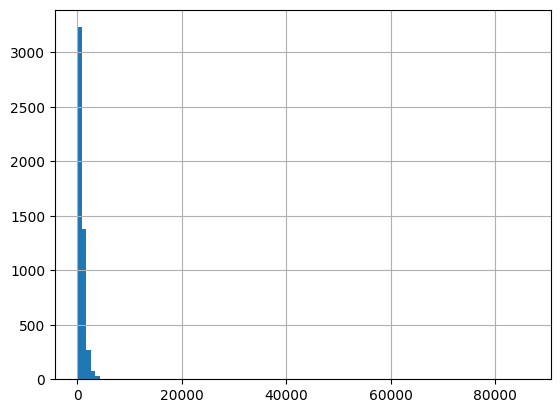

In [ ]:
train['trip_duration'].hist(bins=100)
plt.show()

Heavily skewed distribution, will likely need to apply log1p.

In [ ]:
train['target'] = np.log1p(train['trip_duration'])

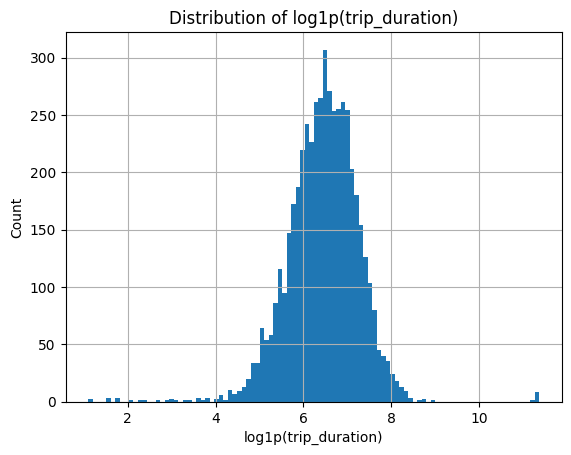

In [ ]:
ax = train['target'].hist(bins = 100)
ax.set_title('Distribution of log1p(trip_duration)')
ax.set_xlabel('log1p(trip_duration)')
ax.set_ylabel('Count')
plt.show()


After applying the log1p transformation, the trip duration is roughly okay and the distribution is centered around 11 minutes. Tails on both ends, however, correspond to extreme outliers.

## 3. Data Cleaning
To ensure our model isn't confused by noise, we filter for valid NYC coordinates and realistic trip durations (between 5 minutes and 4 hours).

During model testing later I updated the trip durations to 1 minute and 4 hours which massively improved the score on the ridge model.

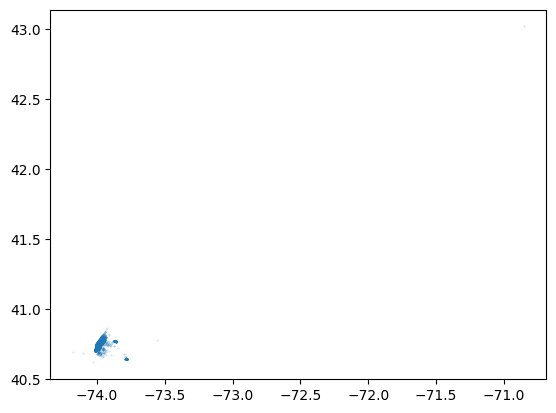

In [ ]:
plt.scatter(train['pickup_longitude'], train['pickup_latitude'], s=0.1, alpha=0.3)

The outliers are very weird and need to be removed.

In [ ]:
# before cleaning
print("Before:", len(train))

train = train[
    (train['pickup_latitude'].between(40.5, 41.0)) &
    (train['pickup_longitude'].between(-74.3, -73.6)) &
    (train['dropoff_latitude'].between(40.5, 41.0)) &
    (train['dropoff_longitude'].between(-74.3, -73.6)) &
    (train['trip_duration'] >= 300) & # 5 minutes
    (train['trip_duration'] <= 14400)  # The cutoff is 4 hours here
]

print("After:", len(train))

Before: 5000
After: 4233


~700 rows removed due to coordinates outside NYC bounds or implausible trip durations. Cleaned dataset retains 4233 rows.

In [ ]:
train['passenger_count'].value_counts().sort_index()

,count
passenger_count,
1,2988
2,624
3,177
4,73
5,254
6,117


Passenger counts range from 1-6, all within legal NYC taxi capacity. No cleaning needed. Pretty cool!

In [ ]:
train[['passenger_count', 'trip_duration']].corr()

,passenger_count,trip_duration
passenger_count,1.000000,0.022353
trip_duration,0.022353,1.000000


Okay so no correlation between passenger count and trip duration.

### Feature Engineering
In this section, we extract temporal features from the `pickup_datetime` to capture patterns related to time of day and day of the week, which are likely to influence trip duration due to traffic conditions.

### 4.1 Temporal Features
Traffic patterns change based on when a trip occurs. We extract the hour, day of the week, and month from the pickup timestamp.

In [ ]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
train['hour'] = train['pickup_datetime'].dt.hour
train['dow'] = train['pickup_datetime'].dt.dayofweek
train['month'] = train['pickup_datetime'].dt.month

<Axes: xlabel='hour'>

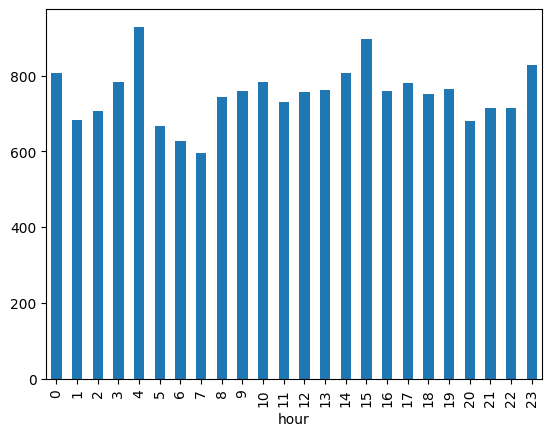

In [ ]:
train.groupby('hour')['trip_duration'].median().plot(kind='bar')

**Trip duration** remains relatively *stable* across hours with no strong rush-hour spikes observed. A noticeable increase occurs around 4 AM, likely due to a higher proportion of long-distance trips such as airport travel rather than traffic congestion. Overall, time-of-day effects appear weaker than expected.

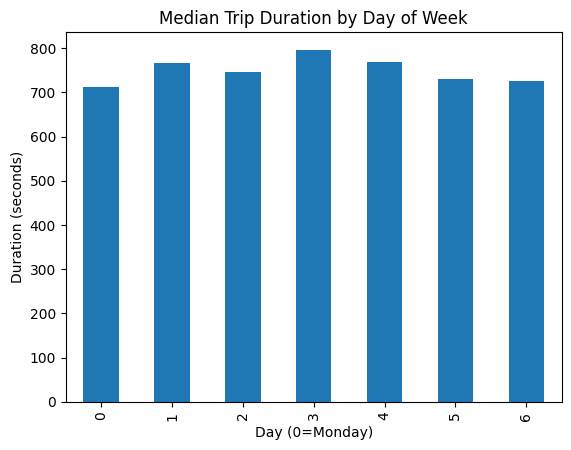

In [ ]:
train.groupby('dow')['trip_duration'].median().plot(kind='bar')
plt.title('Median Trip Duration by Day of Week')
plt.xlabel('Day (0=Monday)')
plt.ylabel('Duration (seconds)')
plt.show()

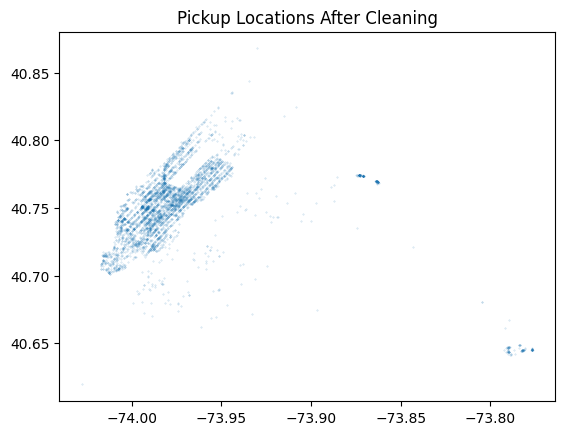

In [ ]:
plt.scatter(train['pickup_longitude'], train['pickup_latitude'], s=0.1, alpha=0.3)
plt.title('Pickup Locations After Cleaning')
plt.show()

After cleaning, pickup locations form three recognizable clusters: Manhattan (dominant), LaGuardia Airport, and JFK Airport. This confirms the cleaning bounds were appropriate and no legitimate NYC trips were removed.

Although we should account for airport trips vs non-airport trips leading to the creation of the next feature.

### 4.2 Spatial Features & Distance
By identifying airport-related trips and calculating the 'as-the-crow-flies' Haversine distance, we provide the model with its most predictive signals.

In [ ]:
def is_airport(lat, lon):
    return (
        (lat.between(40.62, 40.67) & lon.between(-73.82, -73.74)) |  # JFK
        (lat.between(40.75, 40.79) & lon.between(-73.90, -73.84))    # LGA
    )

train['pickup_airport'] = is_airport(train['pickup_latitude'], train['pickup_longitude']).astype(int)
train['dropoff_airport'] = is_airport(train['dropoff_latitude'], train['dropoff_longitude']).astype(int)

In [ ]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 #  Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

### Distance Calculation
To improve our model, we calculate the Haversine distance between pickup and dropoff coordinates. This provides a 'straight-line' distance which acts as a strong proxy for trip duration.

In [ ]:
train['distance_km'] = haversine(
    train['pickup_latitude'],
    train['pickup_longitude'],
    train['dropoff_latitude'],
    train['dropoff_longitude']
)

In [ ]:
train['distance_km'].describe()

,distance_km
count,4233.000000
mean,3.850630
std,4.001846
min,0.000000
25%,1.541899
50%,2.431866
75%,4.333437
max,24.343294


Minimum distance being 0 is very weird here. I'll try to look at it with duration.

In [ ]:
train[train['distance_km'] == 0][['trip_duration']].describe()

,trip_duration
count,14.000000
mean,1027.642857
std,687.652708
min,336.000000
25%,575.000000
50%,699.000000
75%,1356.750000
max,2291.000000


**Observation on Zero-Distance Trips:** There are a few records where the calculated distance is 0 km, yet the trip duration is several minutes. These may represent trips where the passenger changed their mind or returned to the starting point. Given their small number, they likely won't negatively impact the Ridge model significantly, but they are important anomalies to note.

<Axes: >

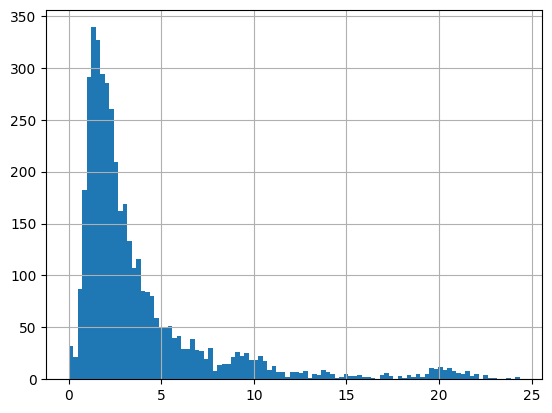

In [ ]:
train['distance_km'].hist(bins=100)

In [ ]:
train[['distance_km', 'trip_duration']].corr()

,distance_km,trip_duration
distance_km,1.000000,0.750183
trip_duration,0.750183,1.000000


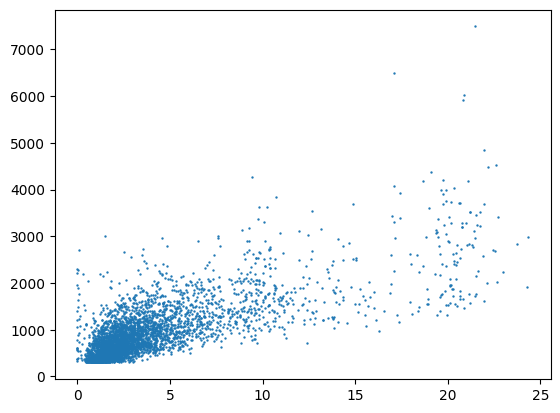

In [ ]:
plt.scatter(train['distance_km'], train['trip_duration'], s=0.5)

### Correlation Analysis
The scatter plot and correlation matrix confirm a strong linear relationship (r ≈ 0.75) between `distance_km` and `trip_duration`. This confirms that distance will be one of our most predictive features for the Ridge Regression model.

## 5. Final Correlation & Hypothesis Testing
Before moving to modeling, we check if our engineered features (like distance and weekend status) actually correlate with our target variable.

In [ ]:
train['store_and_fwd_flag'] = (train['store_and_fwd_flag'] == 'Y').astype(int)

<Axes: xlabel='store_and_fwd_flag'>

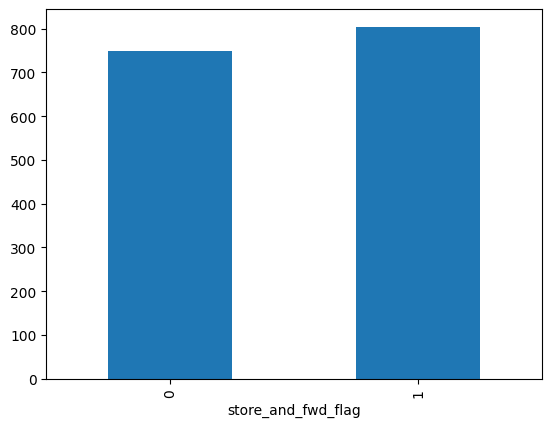

In [ ]:
train.groupby('store_and_fwd_flag')['trip_duration'].median().plot(kind='bar')

The store_and_fwd_flag feature has little to no correlation with the trip duration and is safe to discard if need to be. Not necessary since ridge regression will deal with it automatically.

In [ ]:
train['is_weekend'] = (train['dow'] >= 5).astype(int)
train[['distance_km', 'is_weekend']].corr()

,distance_km,is_weekend
distance_km,1.000000,0.041703
is_weekend,0.041703,1.000000


No correlation between it being a weekend day and the distance traveled either.

## EDA Conclusion & Next Steps
- **Data Quality:** Handled extreme outliers in both spatial (lat/long) and temporal (duration) dimensions.
- **Feature Engineering:** Extracted `hour`, `day of week`, and calculated `haversine distance`.
- **Target Normalization:** Log-transformed the target to handle skewness.
- **Insights:** Distance is a primary driver, while time-of-day shows subtle patterns suggesting different trip types (e.g., airport runs in the early morning).

**Next Phase:** Prepare the training script for the Ridge(alpha=1) model using these engineered features.